# Проект: Анализ прогнозного горизонта — модели и стратегии

**Гипотеза:** Разные модели и разные стратегии прогнозирования конкурентоспособны на разных участках прогнозного горизонта.

## Постановка задачи

Цель проекта — проверить, что выбор лучшей модели зависит от шага прогнозного горизонта h. Для этого:
- Зафиксированы бейзлайны: Naive, SeasonalNaive, AutoTheta, AutoETS
- Две глобальные модели: CatBoost и PatchTST (в MIMO стратегии)
- Для CatBoost дополнительно сравниваются Recursive и Direct стратегии
- Качество оценивается не только по усреднённой метрике, но и **в разрезе каждого шага прогнозирования** h=1..18

## Данные

M4 Monthly — 150 случайных временных рядов (seed=42), горизонт прогнозирования h=18.

## Метрики

- **sMAPE** (symmetric Mean Absolute Percentage Error) — основная метрика M4 соревнования
- **MASE** (Mean Absolute Scaled Error) — масштабно-инвариантная метрика

# Импорты

In [ ]:
!pip install -q pandas numpy matplotlib seaborn catboost statsforecast neuralforecast datasetsforecast

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.6/275.6 kB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.0/73.0 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
from datasetsforecast.m4 import M4
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
import math

from typing import Dict, List, Tuple
from tqdm import tqdm

from statsforecast import StatsForecast
from statsforecast.models import Naive, SeasonalNaive, AutoTheta, AutoETS
from catboost import CatBoostRegressor

sns.set_theme(style="whitegrid", font_scale=1.1)

# Параметры

In [ ]:
DATASET = "M4"
FREQUENCY = "Monthly"
N_SERIES = 150
HORIZON = 18
SEASON_LENGTH = 12
RANDOM_SEED = 42

LAGS = list(range(1, 25))
CALENDAR_FEATURES = ["month"]

CATBOOST_PARAMS_MIMO = {
    "iterations": 1000,
    "learning_rate": 0.05,
    "depth": 6,
    "l2_leaf_reg": 3.0,
    "loss_function": "MultiRMSE",
    "random_seed": RANDOM_SEED,
    "verbose": 0,
    "early_stopping_rounds": 50
}

CATBOOST_PARAMS_1STEP = {
    "iterations": 1000,
    "learning_rate": 0.05,
    "depth": 6,
    "l2_leaf_reg": 3.0,
    "loss_function": "RMSE",
    "random_seed": RANDOM_SEED,
    "verbose": 0,
    "early_stopping_rounds": 50,
    "task_type": "GPU",
    "devices": "0"
}

PATCHTST_PARAMS = {
    "input_size": 48,
    "h": HORIZON,
    "max_steps": 500,
    "learning_rate": 1e-3,
    "batch_size": 32,
    "patch_len": 12,
    "stride": 12,
    "hidden_size": 64,
    "n_heads": 4,
    "encoder_layers": 2,
    "random_seed": RANDOM_SEED,
    "early_stop_patience_steps": 10,
    "val_check_steps": 50,
    "scaler_type": "standard",
}

In [ ]:
data = M4.load(directory="data", group="Monthly")

91.7MiB [00:01, 73.6MiB/s]
7.94MiB [00:00, 48.9MiB/s]
4.34MiB [00:00, 115MiB/s]                  
100%|██████████| 3.56M/3.56M [00:00<00:00, 55.3MiB/s]


In [ ]:
len(data)

3

In [ ]:
data

(         unique_id  ds       y
 0               M1   1  8000.0
 1               M1   2  8350.0
 2               M1   3  8570.0
 3               M1   4  7700.0
 4               M1   5  7080.0
 ...            ...  ..     ...
 11246406     M9999  83  4200.0
 11246407     M9999  84  4300.0
 11246408     M9999  85  3800.0
 11246409     M9999  86  4400.0
 11246410     M9999  87  4300.0
 
 [11246411 rows x 3 columns],
 None,
       unique_id  category
 0            M1         3
 1           M10         3
 2          M100         3
 3         M1000         3
 4        M10000         3
 ...         ...       ...
 47995     M9995         3
 47996     M9996         3
 47997     M9997         3
 47998     M9998         3
 47999     M9999         3
 
 [48000 rows x 2 columns])

In [ ]:
train_full = data[0]
meta = data[2]

In [ ]:
train_full

,unique_id,ds,y
0,M1,1,8000.0
1,M1,2,8350.0
2,M1,3,8570.0
3,M1,4,7700.0
4,M1,5,7080.0
...,...,...,...
11246406,M9999,83,4200.0
11246407,M9999,84,4300.0
11246408,M9999,85,3800.0
11246409,M9999,86,4400.0


In [ ]:
meta

,unique_id,category
0,M1,3
1,M10,3
2,M100,3
3,M1000,3
4,M10000,3
...,...,...
47995,M9995,3
47996,M9996,3
47997,M9997,3
47998,M9998,3


В датасете, который я скачала, 48к рядов. Для моей задачи это слишком много, я возьму 150 случайных.

In [ ]:
def prepare_m4_data(train_full, n_series=150, seed=42, horizon=18):

    all_ids = train_full["unique_id"].unique()
    rng = np.random.RandomState(seed)
    sampled_ids = rng.choice(all_ids, size=min(n_series, len(all_ids)), replace=False)

    df = train_full[train_full["unique_id"].isin(sampled_ids)].copy()
    # сортирую записи по времени
    df = df.sort_values(["unique_id", "ds"]).reset_index(drop=True)

    train_parts = []
    test_parts = []

    for uid, grp in df.groupby("unique_id"):
        # сортирую запись по времени
        grp = grp.sort_values("ds").reset_index(drop=True)

        if len(grp) <= horizon:
            continue

        # убираю горизонт прогнозирования из трейна
        train_part = grp.iloc[:-horizon].copy()
        test_part = grp.iloc[-horizon:].copy()
        # добавляю столбец с шагами прогнозного горизонта
        test_part["h"] = range(1, len(test_part) + 1)

        train_parts.append(train_part)
        test_parts.append(test_part)

    train_df = pd.concat(train_parts, ignore_index=True)
    test_df = pd.concat(test_parts, ignore_index=True)

    return train_df, test_df, sampled_ids

In [ ]:
train_df, test_df, sampled_ids = prepare_m4_data(
    train_full,
    n_series=150,
    seed=42,
    horizon=18
)

print("train_df shape:", train_df.shape)
print("test_df shape:", test_df.shape)
print(train_df.head())
print(test_df.head())

train_df shape: (31078, 3)
test_df shape: (2700, 4)
  unique_id ds       y
0    M10000  1  4060.0
1    M10000  2  4230.0
2    M10000  3  4480.0
3    M10000  4  4600.0
4    M10000  5  4400.0
  unique_id  ds       y  h
0    M10000  70  2580.0  1
1    M10000  71  2220.0  2
2    M10000  72  2010.0  3
3    M10000  73  1640.0  4
4    M10000  74  1680.0  5


In [ ]:
print("Число рядов в train:", train_df["unique_id"].nunique())
print("Число рядов в test:", test_df["unique_id"].nunique())

print("Минимальный ds в train:", train_df["ds"].min())
print("Максимальный ds в train:", train_df["ds"].max())

print("Шаги горизонта в test:", sorted(test_df["h"].unique()))
print("Размер test на один ряд:")
print(test_df.groupby("unique_id").size().describe())

Число рядов в train: 150
Число рядов в test: 150
Минимальный ds в train: 1
Максимальный ds в train: 822
Шаги горизонта в test: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18)]
Размер test на один ряд:
count    150.0
mean      18.0
std        0.0
min       18.0
25%       18.0
50%       18.0
75%       18.0
max       18.0
dtype: float64


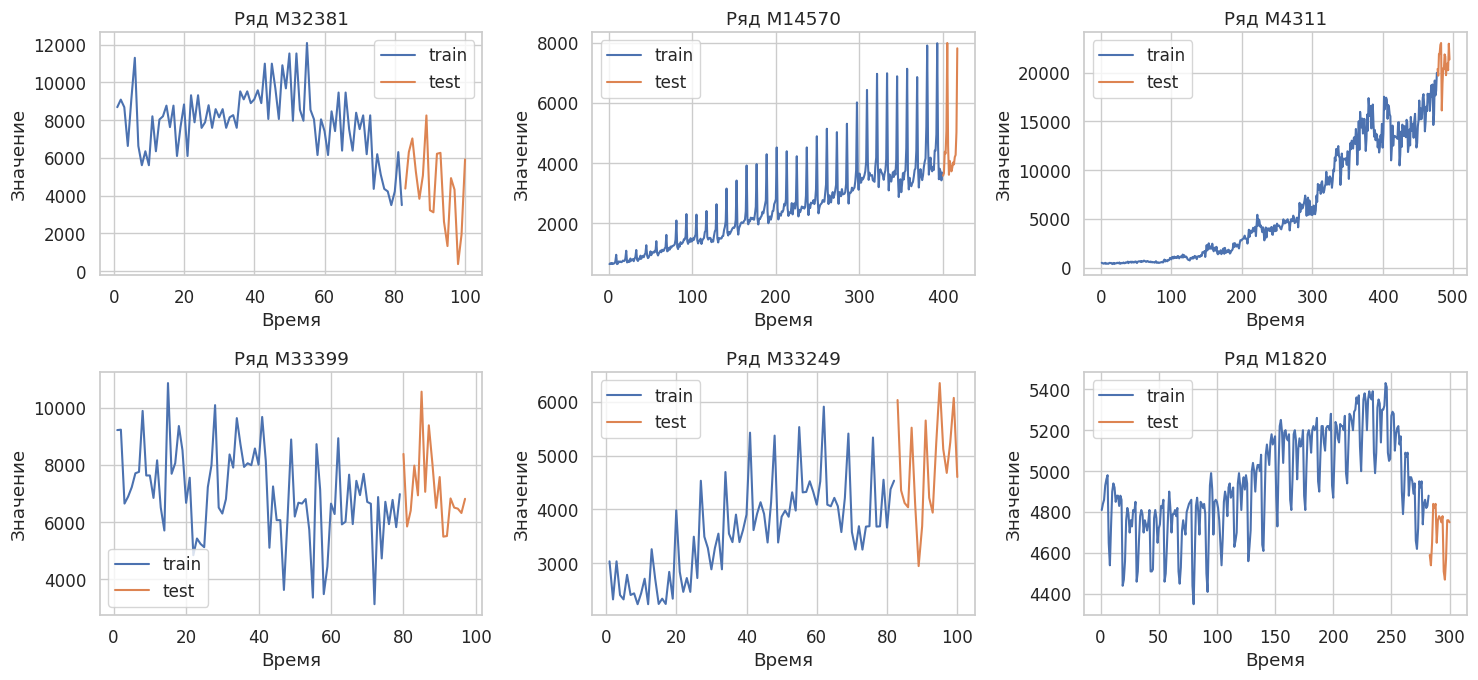

In [ ]:
%matplotlib inline

# сколько рядов хотим показать
n_plots = 6

# берём только уникальные id
unique_uids = train_df["unique_id"].drop_duplicates().to_numpy()

# случайно выбираем без повторений
rng = np.random.RandomState(42)
sample_uids = rng.choice(unique_uids, size=min(n_plots, len(unique_uids)), replace=False)

# параметры сетки
n_cols = 3
n_rows = math.ceil(len(sample_uids) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows), squeeze=False)
axes = axes.flatten()

for i, uid in enumerate(sample_uids):
    tr = train_df[train_df["unique_id"] == uid]
    te = test_df[test_df["unique_id"] == uid]

    ax = axes[i]
    ax.plot(tr["ds"], tr["y"], label="train")
    ax.plot(te["ds"], te["y"], label="test")
    ax.set_title(f"Ряд {uid}")
    ax.set_xlabel("Время")
    ax.set_ylabel("Значение")
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
sample_uids

array(['M32381', 'M14570', 'M4311', 'M33399', 'M33249', 'M1820'],
      dtype=object)

# Бейзлайны

In [ ]:
print(train_df.dtypes)
print(train_df["ds"].head())

unique_id     object
ds            object
y            float64
dtype: object
0    1
1    2
2    3
3    4
4    5
Name: ds, dtype: object


In [ ]:
train_df = train_df.copy()
test_df = test_df.copy()

train_df["ds"] = train_df["ds"].astype(int)
test_df["ds"] = test_df["ds"].astype(int)

In [ ]:
SEASON_LENGTH = 12

def fit_baselines(train_df):
    models = [
        Naive(),
        SeasonalNaive(season_length=SEASON_LENGTH),
        AutoTheta(season_length=SEASON_LENGTH),
        AutoETS(season_length=SEASON_LENGTH),
    ]

    sf = StatsForecast(
        models=models,
        freq=1,
        n_jobs=-1,
    )

    forecasts = sf.forecast(df=train_df, h=HORIZON)
    return forecasts.reset_index()

In [ ]:
baseline_forecasts = fit_baselines(train_df)
baseline_forecasts.head()

,index,unique_id,ds,Naive,SeasonalNaive,AutoTheta,AutoETS
0,0,M10000,70,2780.0,2360.0,2754.120575,2780.001999
1,1,M10000,71,2780.0,2440.0,2728.314012,2780.001999
2,2,M10000,72,2780.0,2220.0,2702.507449,2780.001999
3,3,M10000,73,2780.0,1980.0,2676.700886,2780.001999
4,4,M10000,74,2780.0,2100.0,2650.894323,2780.001999


# Метрики

In [ ]:
def baseline_to_long(forecasts, model_name):
    df = forecasts[["unique_id", model_name]].copy()
    df["h"] = df.groupby("unique_id").cumcount() + 1
    df = df.rename(columns={model_name: "prediction"})
    return df[["unique_id", "h", "prediction"]]


naive_preds = baseline_to_long(baseline_forecasts, "Naive")
seasonal_preds = baseline_to_long(baseline_forecasts, "SeasonalNaive")
theta_preds = baseline_to_long(baseline_forecasts, "AutoTheta")
ets_preds = baseline_to_long(baseline_forecasts, "AutoETS")

In [ ]:
def smape(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)

    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denom > 0

    if mask.sum() == 0:
        return 0.0

    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100


def mase(y_true, y_pred, y_train, season_length=12):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    y_train = np.array(y_train, dtype=float)

    if len(y_train) <= season_length:
        return np.nan

    naive_errors = np.abs(y_train[season_length:] - y_train[:-season_length])
    scale = np.mean(naive_errors)

    if scale == 0 or np.isnan(scale):
        return np.nan

    return np.mean(np.abs(y_true - y_pred)) / scale

In [ ]:
train_series = {
    uid: grp["y"].values
    for uid, grp in train_df.groupby("unique_id")
}

In [ ]:
def compute_per_step_metrics(test_df, preds_df, train_series):
    merged = test_df.merge(preds_df, on=["unique_id", "h"], how="inner")

    results = []

    for h in sorted(merged["h"].unique()):
        step_data = merged[merged["h"] == h]

        smape_vals = []
        mase_vals = []

        for _, row in step_data.iterrows():
            uid = row["unique_id"]

            y_true = np.array([row["y"]])
            y_pred = np.array([row["prediction"]])

            smape_vals.append(smape(y_true, y_pred))

            if uid in train_series:
                m = mase(y_true, y_pred, train_series[uid], season_length=12)
                if not np.isnan(m):
                    mase_vals.append(m)

        results.append({
            "h": int(h),
            "sMAPE": float(np.mean(smape_vals)) if len(smape_vals) > 0 else np.nan,
            "MASE": float(np.mean(mase_vals)) if len(mase_vals) > 0 else np.nan,
        })

    return pd.DataFrame(results)

def compute_aggregated_metrics(test_df, preds_df, train_series):
    merged = test_df.merge(preds_df, on=["unique_id", "h"], how="inner")

    smape_vals = []
    mase_vals = []

    for uid, grp in merged.groupby("unique_id"):
        y_true = grp["y"].values
        y_pred = grp["prediction"].values

        smape_vals.append(smape(y_true, y_pred))

        if uid in train_series:
            m = mase(y_true, y_pred, train_series[uid], season_length=12)
            if not np.isnan(m):
                mase_vals.append(m)

    return {
        "sMAPE": float(np.mean(smape_vals)) if len(smape_vals) > 0 else np.nan,
        "MASE": float(np.mean(mase_vals)) if len(mase_vals) > 0 else np.nan,
    }

In [ ]:
models_preds = {
    "Naive": naive_preds,
    "SeasonalNaive": seasonal_preds,
    "AutoTheta": theta_preds,
    "AutoETS": ets_preds,
}

all_per_step = {}
all_agg = {}

for model_name, preds_df in models_preds.items():
    print(f"Метрики для {model_name}...")

    per_step_df = compute_per_step_metrics(test_df, preds_df, train_series)
    agg_metrics = compute_aggregated_metrics(test_df, preds_df, train_series)

    all_per_step[model_name] = per_step_df
    all_agg[model_name] = agg_metrics

    print(f"{model_name}: sMAPE = {agg_metrics['sMAPE']:.4f}, MASE = {agg_metrics['MASE']:.4f}")


Метрики для Naive...
Naive: sMAPE = 17.0560, MASE = 1.1817
Метрики для SeasonalNaive...
SeasonalNaive: sMAPE = 17.5449, MASE = 1.1932
Метрики для AutoTheta...
AutoTheta: sMAPE = 14.1453, MASE = 0.9390
Метрики для AutoETS...
AutoETS: sMAPE = 14.6157, MASE = 0.9114


In [ ]:
summary_df = pd.DataFrame([
    {"Модель": model_name, **metrics}
    for model_name, metrics in all_agg.items()
]).sort_values("sMAPE").reset_index(drop=True)

summary_df

,Модель,sMAPE,MASE
0,AutoTheta,14.145286,0.938953
1,AutoETS,14.615678,0.911432
2,Naive,17.056005,1.181691
3,SeasonalNaive,17.544905,1.193225


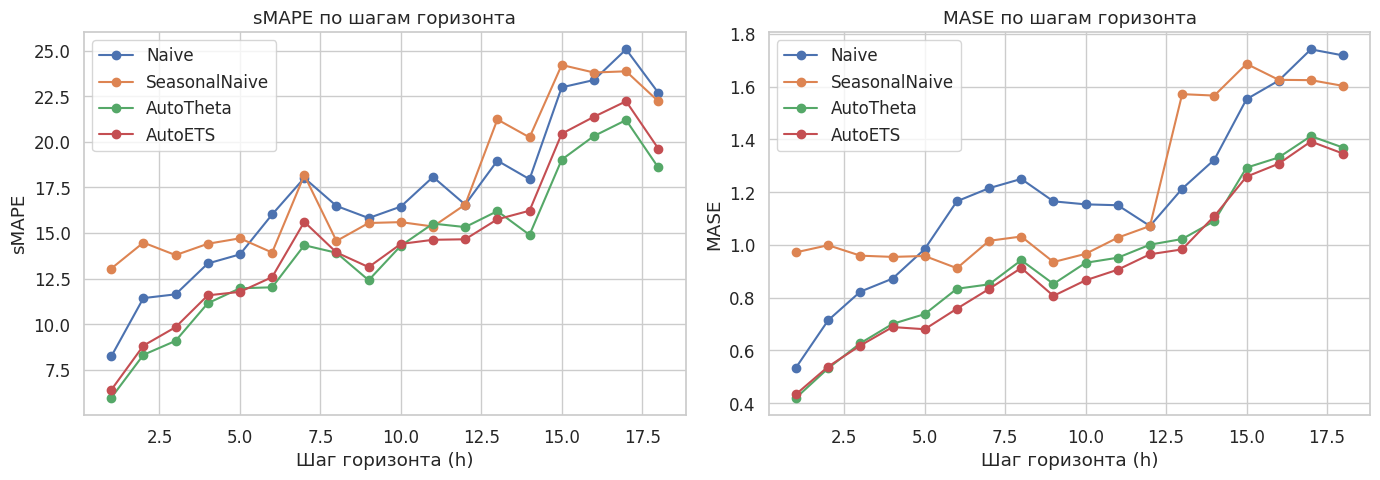

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for model_name, df in all_per_step.items():
    axes[0].plot(df["h"], df["sMAPE"], marker="o", label=model_name)

axes[0].set_xlabel("Шаг горизонта (h)")
axes[0].set_ylabel("sMAPE")
axes[0].set_title("sMAPE по шагам горизонта")
axes[0].grid(True)
axes[0].legend()

for model_name, df in all_per_step.items():
    axes[1].plot(df["h"], df["MASE"], marker="o", label=model_name)

axes[1].set_xlabel("Шаг горизонта (h)")
axes[1].set_ylabel("MASE")
axes[1].set_title("MASE по шагам горизонта")
axes[1].grid(True)
axes[1].legend()


plt.tight_layout()
plt.show()

# Модели

## Catboost

In [ ]:
LAGS = list(range(1, 25))   # лаги 1..24
SEASON_LENGTH = 12

In [ ]:
def create_lag_features(series, lags):
    features = {}
    n = len(series)

    for lag in lags:
        idx = n - lag
        features[f"lag_{lag}"] = series[idx] if idx >= 0 else np.nan

    return features


def create_rolling_features(series):
    features = {}

    for window in [3, 6, 12]:
        if len(series) >= window:
            features[f"rolling_mean_{window}"] = np.mean(series[-window:])
            features[f"rolling_std_{window}"] = np.std(series[-window:])
        else:
            features[f"rolling_mean_{window}"] = np.nan
            features[f"rolling_std_{window}"] = np.nan

    return features


def create_calendar_features(ds_value, season_length=12):
    # month = номер месяца внутри сезона
    return {"month": int(ds_value % season_length)}

In [ ]:
def build_mimo_dataset(train_df, lags=LAGS, horizon=18):
    X_rows = []
    Y_rows = []

    max_lag = max(lags)

    for uid, grp in train_df.groupby("unique_id"):
        grp = grp.sort_values("ds").reset_index(drop=True)

        values = grp["y"].values
        ds_values = grp["ds"].values

        # sliding windows
        for end_idx in range(max_lag, len(values) - horizon + 1):
            history = values[:end_idx]
            future = values[end_idx:end_idx + horizon]

            feat = create_lag_features(history, lags)
            feat.update(create_rolling_features(history))
            feat.update(create_calendar_features(ds_values[end_idx]))
            feat["unique_id"] = uid

            X_rows.append(feat)
            Y_rows.append({f"y_h{h+1}": future[h] for h in range(horizon)})

    X = pd.DataFrame(X_rows)
    Y = pd.DataFrame(Y_rows)

    return X, Y

In [ ]:
def build_mimo_test_features(train_df, lags=LAGS):
    X_rows = []

    for uid, grp in train_df.groupby("unique_id"):
        grp = grp.sort_values("ds").reset_index(drop=True)

        values = grp["y"].values
        ds_values = grp["ds"].values

        feat = create_lag_features(values, lags)
        feat.update(create_rolling_features(values))
        feat.update(create_calendar_features(ds_values[-1] + 1))
        feat["unique_id"] = uid

        X_rows.append(feat)

    return pd.DataFrame(X_rows)

In [ ]:
X_mimo, Y_mimo = build_mimo_dataset(train_df, lags=LAGS, horizon=HORIZON)

print(X_mimo.shape)
print(Y_mimo.shape)
print(X_mimo.head())
print(Y_mimo.head())

(24928, 32)
(24928, 18)
    lag_1   lag_2   lag_3   lag_4   lag_5   lag_6   lag_7   lag_8   lag_9  \
0  3940.0  3980.0  4280.0  4640.0  4990.0  7200.0  6960.0  5700.0  5320.0   
1  3830.0  3940.0  3980.0  4280.0  4640.0  4990.0  7200.0  6960.0  5700.0   
2  3700.0  3830.0  3940.0  3980.0  4280.0  4640.0  4990.0  7200.0  6960.0   
3  3640.0  3700.0  3830.0  3940.0  3980.0  4280.0  4640.0  4990.0  7200.0   
4  3340.0  3640.0  3700.0  3830.0  3940.0  3980.0  4280.0  4640.0  4990.0   

   lag_10  ...  lag_23  lag_24  rolling_mean_3  rolling_std_3  rolling_mean_6  \
0  5000.0  ...  4230.0  4060.0     4066.666667     151.730756     4838.333333   
1  5320.0  ...  4480.0  4230.0     3916.666667      63.420992     4276.666667   
2  5700.0  ...  4600.0  4480.0     3823.333333      98.092926     4061.666667   
3  6960.0  ...  4400.0  4600.0     3723.333333      79.302515     3895.000000   
4  7200.0  ...  4370.0  4400.0     3560.000000     157.480157     3738.333333   

   rolling_std_6  rolling_

    Для каждого ряда последние val_frac окон — валидация, остальные — трейн.
    X должен содержать колонку unique_id (она будет удалена из результата).
    Y может быть DataFrame (MIMO) или Series (1-step).

In [ ]:
def temporal_train_val_split(X, Y, uid_col="unique_id", val_frac=0.15):
    train_idx = []
    val_idx = []

    for uid, grp in X.groupby(uid_col):
        idx = grp.index.tolist()
        split_point = int(len(idx) * (1 - val_frac))
        train_idx.extend(idx[:split_point])
        val_idx.extend(idx[split_point:])

    feat_cols = [c for c in X.columns if c != uid_col]

    X_train = X.loc[train_idx, feat_cols]
    X_val = X.loc[val_idx, feat_cols]

    if isinstance(Y, pd.DataFrame):
        Y_train = Y.loc[train_idx]
        Y_val = Y.loc[val_idx]
    else:
        Y_train = Y.loc[train_idx]
        Y_val = Y.loc[val_idx]

    return X_train, X_val, Y_train, Y_val

In [ ]:
X_train_m, X_val_m, Y_train_m, Y_val_m = temporal_train_val_split(
    X_mimo, Y_mimo, uid_col="unique_id", val_frac=0.15
)

cb_mimo = CatBoostRegressor(**CATBOOST_PARAMS_MIMO)
cb_mimo.fit(
    X_train_m, Y_train_m,
    eval_set=(X_val_m, Y_val_m),
    cat_features=["month"] if "month" in X_train_m.columns else [],
)

CatBoostRegressor(depth=6, early_stopping_rounds=50, iterations=1000, l2_leaf_reg=3.0, learning_rate=0.05, loss_function='MultiRMSE', random_seed=42, verbose=0)

In [ ]:
feature_cols = [c for c in X_mimo.columns if c != "unique_id"]

X_test_mimo = build_mimo_test_features(train_df, lags=LAGS)
uids_test = X_test_mimo["unique_id"].values

mimo_preds = cb_mimo.predict(X_test_mimo[feature_cols])

if mimo_preds.ndim == 1:
    mimo_preds = mimo_preds.reshape(-1, HORIZON)

rows = []
for i, uid in enumerate(uids_test):
    for h in range(HORIZON):
        rows.append({
            "unique_id": uid,
            "h": h + 1,
            "prediction": mimo_preds[i, h]
        })

catboost_mimo_preds = pd.DataFrame(rows)

print(catboost_mimo_preds.head())
print(catboost_mimo_preds.shape)

  unique_id  h   prediction
0    M10000  1  2495.971314
1    M10000  2  2489.671827
2    M10000  3  2482.712962
3    M10000  4  2477.522192
4    M10000  5  2489.993840
(2700, 3)


In [ ]:
cb_mimo_per_step = compute_per_step_metrics(test_df, catboost_mimo_preds, train_series)
cb_mimo_agg = compute_aggregated_metrics(test_df, catboost_mimo_preds, train_series)

print("CatBoost Metrics:")
print(cb_mimo_agg)

CatBoost Metrics:
{'sMAPE': 17.527066274589288, 'MASE': 1.4816594439988615}


In [ ]:
all_per_step["CatBoost_MIMO"] = cb_mimo_per_step
all_agg["CatBoost_MIMO"] = cb_mimo_agg

# обновлённая таблица
summary_df = pd.DataFrame([
    {"Модель": model_name, **metrics}
    for model_name, metrics in all_agg.items()
]).sort_values("sMAPE").reset_index(drop=True)

summary_df.head(10)

,Модель,sMAPE,MASE
0,AutoTheta,14.145286,0.938953
1,AutoETS,14.615678,0.911432
2,Naive,17.056005,1.181691
3,CatBoost_MIMO,17.527066,1.481659
4,SeasonalNaive,17.544905,1.193225


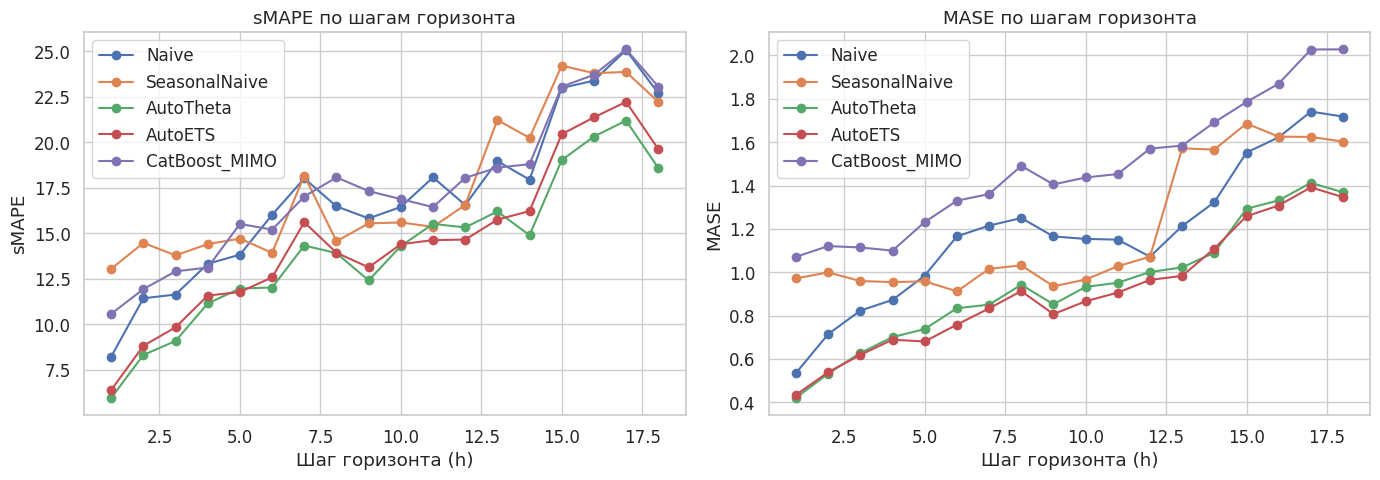

In [ ]:
# Обновлённый график с бейзлайнами + CatBoost MIMO
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for model_name, df in all_per_step.items():
    axes[0].plot(df["h"], df["sMAPE"], marker="o", label=model_name)

axes[0].set_xlabel("Шаг горизонта (h)")
axes[0].set_ylabel("sMAPE")
axes[0].set_title("sMAPE по шагам горизонта")
axes[0].grid(True)
axes[0].legend()

for model_name, df in all_per_step.items():
    axes[1].plot(df["h"], df["MASE"], marker="o", label=model_name)

axes[1].set_xlabel("Шаг горизонта (h)")
axes[1].set_ylabel("MASE")
axes[1].set_title("MASE по шагам горизонта")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

## CatBoost Recursive

In [ ]:
def build_recursive_dataset(train_df, lags=LAGS):
    X_rows = []
    y_list = []

    max_lag = max(lags)

    for uid, grp in train_df.groupby("unique_id"):
        grp = grp.sort_values("ds").reset_index(drop=True)

        values = grp["y"].values
        ds_values = grp["ds"].values

        for t in range(max_lag, len(values)):
            history = values[:t]

            feat = create_lag_features(history, lags)
            feat.update(create_rolling_features(history))
            feat.update(create_calendar_features(ds_values[t]))
            feat["unique_id"] = uid

            X_rows.append(feat)
            y_list.append(values[t])

    X = pd.DataFrame(X_rows)
    y = pd.Series(y_list, name="y")

    return X, y

In [ ]:
X_rec, y_rec = build_recursive_dataset(train_df, lags=LAGS)

print(X_rec.shape)
print(y_rec.shape)
print(X_rec.head())
print(y_rec.head())

(27478, 32)
(27478,)
    lag_1   lag_2   lag_3   lag_4   lag_5   lag_6   lag_7   lag_8   lag_9  \
0  3940.0  3980.0  4280.0  4640.0  4990.0  7200.0  6960.0  5700.0  5320.0   
1  3830.0  3940.0  3980.0  4280.0  4640.0  4990.0  7200.0  6960.0  5700.0   
2  3700.0  3830.0  3940.0  3980.0  4280.0  4640.0  4990.0  7200.0  6960.0   
3  3640.0  3700.0  3830.0  3940.0  3980.0  4280.0  4640.0  4990.0  7200.0   
4  3340.0  3640.0  3700.0  3830.0  3940.0  3980.0  4280.0  4640.0  4990.0   

   lag_10  ...  lag_23  lag_24  rolling_mean_3  rolling_std_3  rolling_mean_6  \
0  5000.0  ...  4230.0  4060.0     4066.666667     151.730756     4838.333333   
1  5320.0  ...  4480.0  4230.0     3916.666667      63.420992     4276.666667   
2  5700.0  ...  4600.0  4480.0     3823.333333      98.092926     4061.666667   
3  6960.0  ...  4400.0  4600.0     3723.333333      79.302515     3895.000000   
4  7200.0  ...  4370.0  4400.0     3560.000000     157.480157     3738.333333   

   rolling_std_6  rolling_mea

In [ ]:
X_train_r, X_val_r, y_train_r, y_val_r = temporal_train_val_split(
    X_rec, y_rec, uid_col="unique_id", val_frac=0.15
)

cb_recursive = CatBoostRegressor(**CATBOOST_PARAMS_1STEP)
cb_recursive.fit(
    X_train_r, y_train_r,
    eval_set=(X_val_r, y_val_r),
    cat_features=["month"] if "month" in X_train_r.columns else [],
)

CatBoostRegressor(depth=6, devices='0', early_stopping_rounds=50, iterations=1000, l2_leaf_reg=3.0, learning_rate=0.05, loss_function='RMSE', random_seed=42, task_type='GPU', verbose=0)

In [ ]:
def predict_catboost_recursive(model, train_df, lags=LAGS, horizon=HORIZON):
    rows = []
    feature_cols = None

    for uid, grp in train_df.groupby("unique_id"):
        grp = grp.sort_values("ds").reset_index(drop=True)

        values = grp["y"].values.tolist()
        ds_last = int(grp["ds"].values[-1])

        for h in range(horizon):
            arr = np.array(values, dtype=float)

            feat = create_lag_features(arr, lags)
            feat.update(create_rolling_features(arr))
            feat.update(create_calendar_features(ds_last + h + 1))
            feat["unique_id"] = uid

            feat_df = pd.DataFrame([feat])

            if feature_cols is None:
                feature_cols = [c for c in feat_df.columns if c != "unique_id"]

            pred = model.predict(feat_df[feature_cols])[0]

            values.append(pred)

            rows.append({
                "unique_id": uid,
                "h": h + 1,
                "prediction": pred
            })

    return pd.DataFrame(rows)


catboost_recursive_preds = predict_catboost_recursive(
    cb_recursive,
    train_df,
    lags=LAGS,
    horizon=HORIZON
)

print(catboost_recursive_preds.head())
print(catboost_recursive_preds.shape)

  unique_id  h   prediction
0    M10000  1  2601.414929
1    M10000  2  2650.146898
2    M10000  3  2671.032361
3    M10000  4  2646.741963
4    M10000  5  2649.851793
(2700, 3)


In [ ]:
cb_recursive_per_step = compute_per_step_metrics(
    test_df,
    catboost_recursive_preds,
    train_series
)

cb_recursive_agg = compute_aggregated_metrics(
    test_df,
    catboost_recursive_preds,
    train_series
)

print("CatBoost Recursive Metrics:")
print(cb_recursive_agg)

CatBoost Recursive Metrics:
{'sMAPE': 16.493321360255784, 'MASE': 1.2699663297561996}


In [ ]:
all_per_step["CatBoost_Recursive"] = cb_recursive_per_step
all_agg["CatBoost_Recursive"] = cb_recursive_agg

summary_df = pd.DataFrame([
    {"Модель": model_name, **metrics}
    for model_name, metrics in all_agg.items()
]).sort_values("sMAPE").reset_index(drop=True)

summary_df

,Модель,sMAPE,MASE
0,AutoTheta,14.145286,0.938953
1,AutoETS,14.615678,0.911432
2,CatBoost_Recursive,16.493321,1.269966
3,Naive,17.056005,1.181691
4,CatBoost_MIMO,17.527066,1.481659
5,SeasonalNaive,17.544905,1.193225


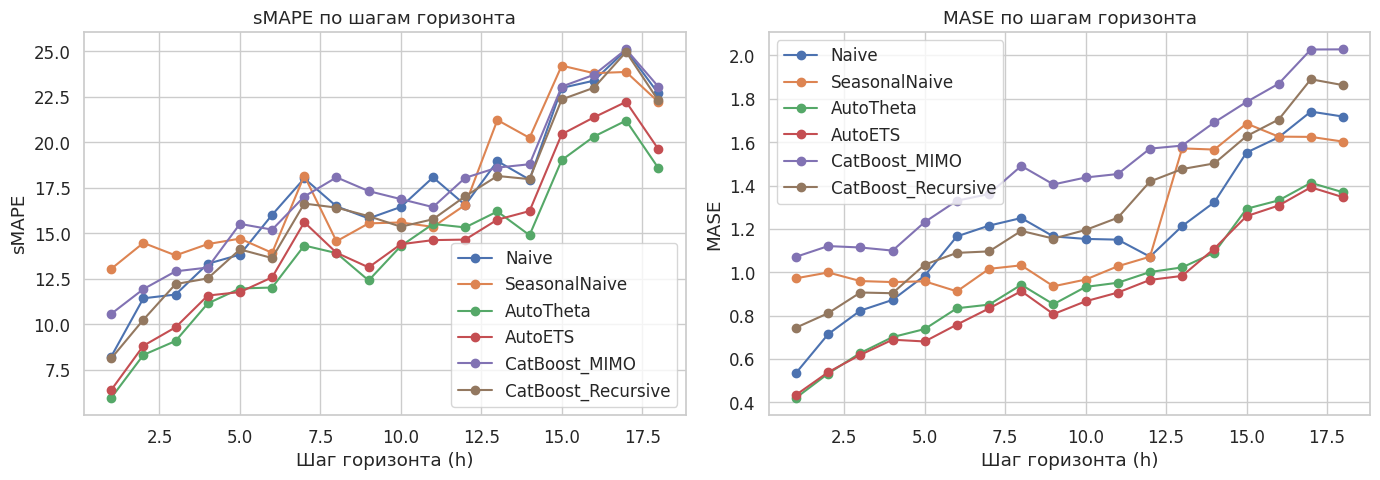

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for model_name, df in all_per_step.items():
    axes[0].plot(df["h"], df["sMAPE"], marker="o", label=model_name)

axes[0].set_xlabel("Шаг горизонта (h)")
axes[0].set_ylabel("sMAPE")
axes[0].set_title("sMAPE по шагам горизонта")
axes[0].grid(True)
axes[0].legend()

for model_name, df in all_per_step.items():
    axes[1].plot(df["h"], df["MASE"], marker="o", label=model_name)

axes[1].set_xlabel("Шаг горизонта (h)")
axes[1].set_ylabel("MASE")
axes[1].set_title("MASE по шагам горизонта")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

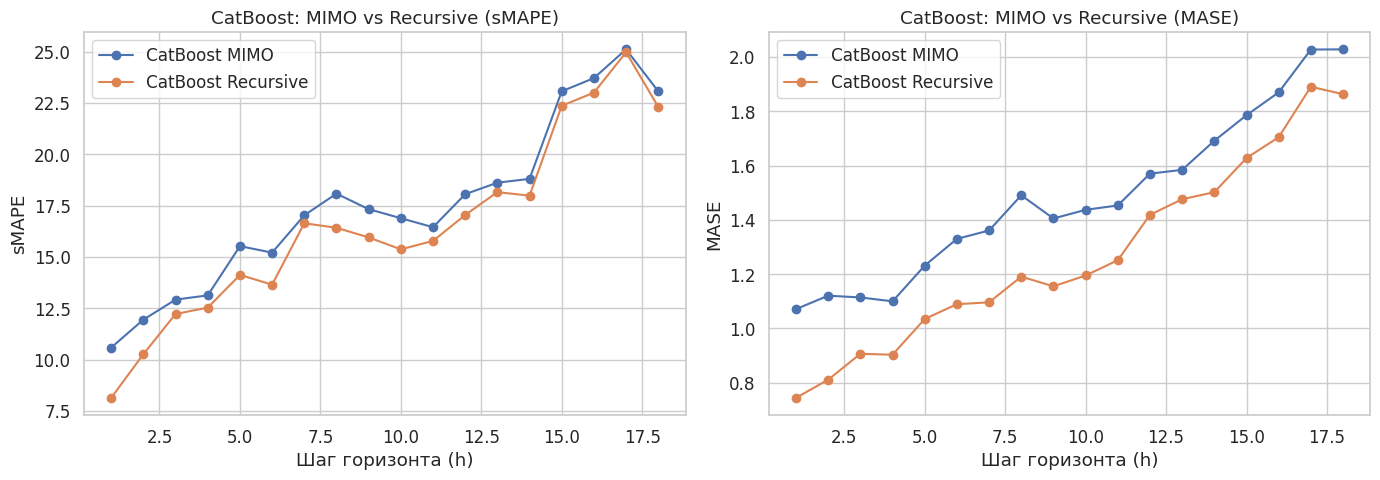

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    all_per_step["CatBoost_MIMO"]["h"],
    all_per_step["CatBoost_MIMO"]["sMAPE"],
    marker="o",
    label="CatBoost MIMO"
)
axes[0].plot(
    all_per_step["CatBoost_Recursive"]["h"],
    all_per_step["CatBoost_Recursive"]["sMAPE"],
    marker="o",
    label="CatBoost Recursive"
)
axes[0].set_xlabel("Шаг горизонта (h)")
axes[0].set_ylabel("sMAPE")
axes[0].set_title("CatBoost: MIMO vs Recursive (sMAPE)")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(
    all_per_step["CatBoost_MIMO"]["h"],
    all_per_step["CatBoost_MIMO"]["MASE"],
    marker="o",
    label="CatBoost MIMO"
)
axes[1].plot(
    all_per_step["CatBoost_Recursive"]["h"],
    all_per_step["CatBoost_Recursive"]["MASE"],
    marker="o",
    label="CatBoost Recursive"
)
axes[1].set_xlabel("Шаг горизонта (h)")
axes[1].set_ylabel("MASE")
axes[1].set_title("CatBoost: MIMO vs Recursive (MASE)")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

## CatBoost Direct

Для стратегии Direct обучаем отдельную модель для каждого шага горизонта h=1..18. Каждая модель предсказывает значение через h шагов вперёд напрямую, без авторегрессии.

In [ ]:
def build_direct_dataset(train_df, step, lags=LAGS):
    """
    Датасет для Direct стратегии: отдельная модель для каждого шага h.
    Таргет — значение через step шагов от конца истории.
    """
    X_rows = []
    y_list = []
    max_lag = max(lags)

    for uid, grp in train_df.groupby("unique_id"):
        grp = grp.sort_values("ds").reset_index(drop=True)
        values = grp["y"].values
        ds_values = grp["ds"].values

        for end_idx in range(max_lag, len(values) - step + 1):
            history = values[:end_idx]
            target = values[end_idx + step - 1]

            feat = create_lag_features(history, lags)
            feat.update(create_rolling_features(history))
            feat.update(create_calendar_features(ds_values[end_idx]))
            feat["unique_id"] = uid

            X_rows.append(feat)
            y_list.append(target)

    X = pd.DataFrame(X_rows)
    y = pd.Series(y_list, name="y")
    return X, y

In [ ]:
direct_models = []

for step in tqdm(range(1, HORIZON + 1)):
    X_d, y_d = build_direct_dataset(train_df, step=step, lags=LAGS)

    X_train_d, X_val_d, y_train_d, y_val_d = temporal_train_val_split(
        X_d, y_d, uid_col="unique_id", val_frac=0.15
    )

    model = CatBoostRegressor(**CATBOOST_PARAMS_1STEP)
    model.fit(
        X_train_d, y_train_d,
        eval_set=(X_val_d, y_val_d),
        cat_features=["month"] if "month" in X_train_d.columns else [],
    )
    direct_models.append(model)

100%|██████████| 18/18 [02:22<00:00,  7.90s/it]


In [ ]:
# Прогноз: каждая модель предсказывает свой шаг горизонта
X_test_direct = build_mimo_test_features(train_df, lags=LAGS)
feat_cols_direct = [c for c in X_test_direct.columns if c != "unique_id"]
uids_direct = X_test_direct["unique_id"].values

rows_direct = []
for h, model in enumerate(direct_models):
    preds = model.predict(X_test_direct[feat_cols_direct])
    for i, uid in enumerate(uids_direct):
        rows_direct.append({
            "unique_id": uid,
            "h": h + 1,
            "prediction": preds[i]
        })

catboost_direct_preds = pd.DataFrame(rows_direct)

# print("Форма предсказаний Direct:", catboost_direct_preds.shape)
catboost_direct_preds.head()

,unique_id,h,prediction
0,M10000,1,2601.414929
1,M10756,1,2767.166633
2,M10766,1,8294.041281
3,M10885,1,1275.855298
4,M11278,1,2169.903146


In [ ]:
# Метрики CatBoost Direct
cb_direct_per_step = compute_per_step_metrics(test_df, catboost_direct_preds, train_series)
cb_direct_agg = compute_aggregated_metrics(test_df, catboost_direct_preds, train_series)

all_per_step["CatBoost_Direct"] = cb_direct_per_step
all_agg["CatBoost_Direct"] = cb_direct_agg

print("CatBoost Direct:")
print(f"sMAPE = {cb_direct_agg['sMAPE']:.4f}")
print(f"MASE = {cb_direct_agg['MASE']:.4f}")

CatBoost Direct:
sMAPE = 16.5951
MASE = 1.3117


## PatchTST (MIMO)

PatchTST — архитектура на основе Transformer, которая работает с патчами (фрагментами) временного ряда. Модель обучается глобально на всех рядах одновременно и предсказывает весь горизонт за один проход (MIMO стратегия встроена в архитектуру).

In [ ]:
from neuralforecast import NeuralForecast
from neuralforecast.models import PatchTST

patchtst_model = PatchTST(**PATCHTST_PARAMS)

nf = NeuralForecast(models=[patchtst_model], freq=1)
nf.fit(df=train_df, val_size=HORIZON)
patchtst_raw = nf.predict()

# привожу к нужному формату
if isinstance(patchtst_raw.index, pd.MultiIndex):
    patchtst_raw = patchtst_raw.reset_index()

patchtst_raw = patchtst_raw.rename(columns={"PatchTST": "prediction"})
patchtst_raw["h"] = patchtst_raw.groupby("unique_id").cumcount() + 1

patchtst_preds = patchtst_raw[["unique_id", "h", "prediction"]].copy()

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE               │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d     │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm      │      0 │ train │     0 │
│ 3 │ model        │ PatchTST_backbone │  106 K │ train │     0 │
└───┴──────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 106 K                                                                                            
Non-trainable params: 2                                                                                            
Total params: 106 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 65                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=500` reached.


INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

In [ ]:
print(patchtst_preds.shape)
patchtst_preds.head()

(2700, 3)


,unique_id,h,prediction
0,M10000,1,2790.925781
1,M10000,2,2747.192139
2,M10000,3,2740.687500
3,M10000,4,2690.836182
4,M10000,5,2783.300293


In [ ]:
ptst_per_step = compute_per_step_metrics(test_df, patchtst_preds, train_series)
ptst_agg = compute_aggregated_metrics(test_df, patchtst_preds, train_series)

all_per_step["PatchTST_MIMO"] = ptst_per_step
all_agg["PatchTST_MIMO"] = ptst_agg

print(f"sMAPE = {ptst_agg['sMAPE']:.4f}")
print(f"MASE = {ptst_agg['MASE']:.4f}")

sMAPE = 16.9302
MASE = 1.1592


# Результаты

## Сводная таблица метрик

In [ ]:
summary_df = pd.DataFrame([
    {"Модель": model_name, **metrics}
    for model_name, metrics in all_agg.items()
]).sort_values("sMAPE").reset_index(drop=True)

In [ ]:
summary_df

,Модель,sMAPE,MASE
0,AutoTheta,14.145286,0.938953
1,AutoETS,14.615678,0.911432
2,CatBoost_Recursive,16.493321,1.269966
3,CatBoost_Direct,16.595134,1.311725
4,PatchTST_MIMO,16.930199,1.159229
5,Naive,17.056005,1.181691
6,CatBoost_MIMO,17.527066,1.481659
7,SeasonalNaive,17.544905,1.193225


In [ ]:
display(summary_df.style.highlight_min(axis=0, subset=["sMAPE", "MASE"], color="lightgreen"))

,Модель,sMAPE,MASE
0,AutoTheta,14.145286,0.938953
1,AutoETS,14.615678,0.911432
2,CatBoost_Recursive,16.493321,1.269966
3,CatBoost_Direct,16.595134,1.311725
4,PatchTST_MIMO,16.930199,1.159229
5,Naive,17.056005,1.181691
6,CatBoost_MIMO,17.527066,1.481659
7,SeasonalNaive,17.544905,1.193225


## Графики sMAPE и MASE по шагам горизонта

Основная визуализация для проверки гипотезы: разные модели и стратегии по-разному ведут себя на разных участках прогнозного горизонта.

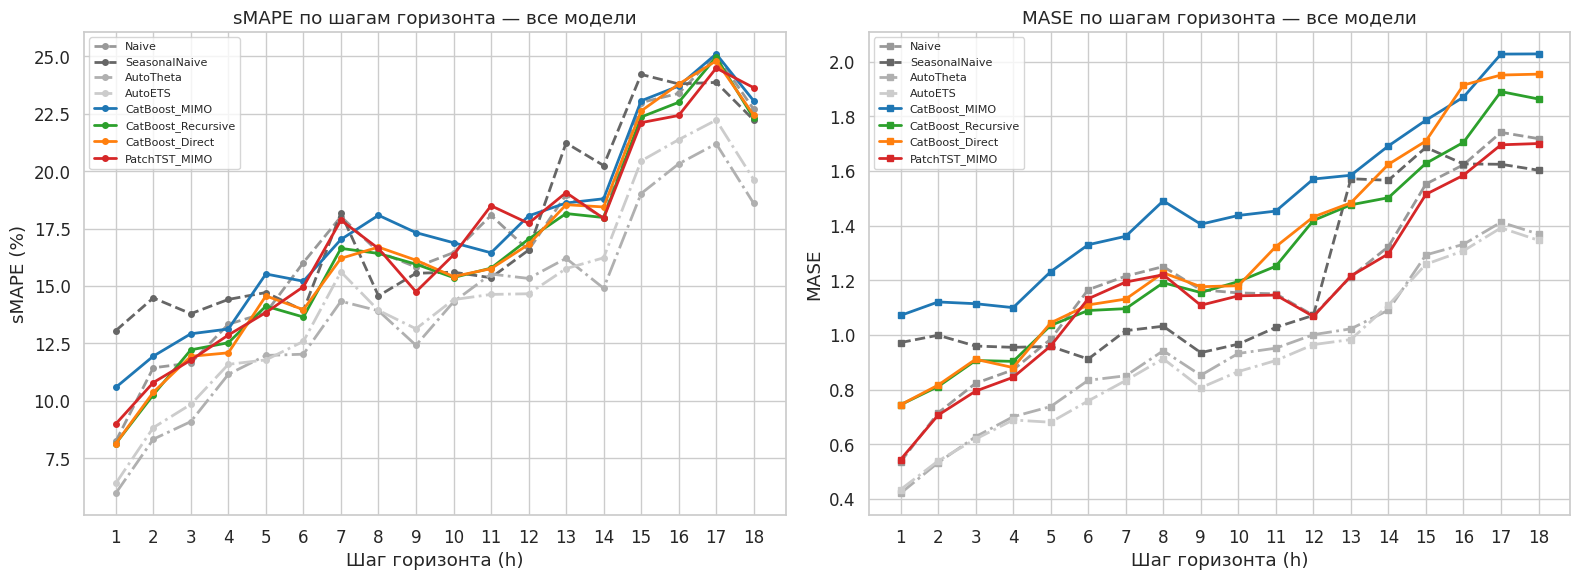

In [ ]:
%matplotlib inline

color_map = {
    "Naive": "#999999",
    "SeasonalNaive": "#666666",
    "AutoTheta": "#b0b0b0",
    "AutoETS": "#cccccc",
    "CatBoost_MIMO": "#1f77b4",
    "CatBoost_Recursive": "#2ca02c",
    "CatBoost_Direct": "#ff7f0e",
    "PatchTST_MIMO": "#d62728",
}

linestyle_map = {
    "Naive": "--",
    "SeasonalNaive": "--",
    "AutoTheta": "-.",
    "AutoETS": "-.",
    "CatBoost_MIMO": "-",
    "CatBoost_Recursive": "-",
    "CatBoost_Direct": "-",
    "PatchTST_MIMO": "-",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for model_name, df in all_per_step.items():
    axes[0].plot(
        df["h"], df["sMAPE"],
        label=model_name,
        color=color_map.get(model_name, None),
        linestyle=linestyle_map.get(model_name, "-"),
        linewidth=2, marker="o", markersize=4,
    )

axes[0].set_xlabel("Шаг горизонта (h)")
axes[0].set_ylabel("sMAPE (%)")
axes[0].set_title("sMAPE по шагам горизонта — все модели")
axes[0].legend(fontsize=8)
axes[0].set_xticks(range(1, HORIZON + 1))
axes[0].grid(True)

for model_name, df in all_per_step.items():
    axes[1].plot(
        df["h"], df["MASE"],
        label=model_name,
        color=color_map.get(model_name, None),
        linestyle=linestyle_map.get(model_name, "-"),
        linewidth=2, marker="s", markersize=4,
    )

axes[1].set_xlabel("Шаг горизонта (h)")
axes[1].set_ylabel("MASE")
axes[1].set_title("MASE по шагам горизонта — все модели")
axes[1].legend(fontsize=8)
axes[1].set_xticks(range(1, HORIZON + 1))
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Сравнение стратегий CatBoost: MIMO vs Recursive vs Direct

Это центральное сравнение для проверки гипотезы о различиях стратегий прогнозирования.

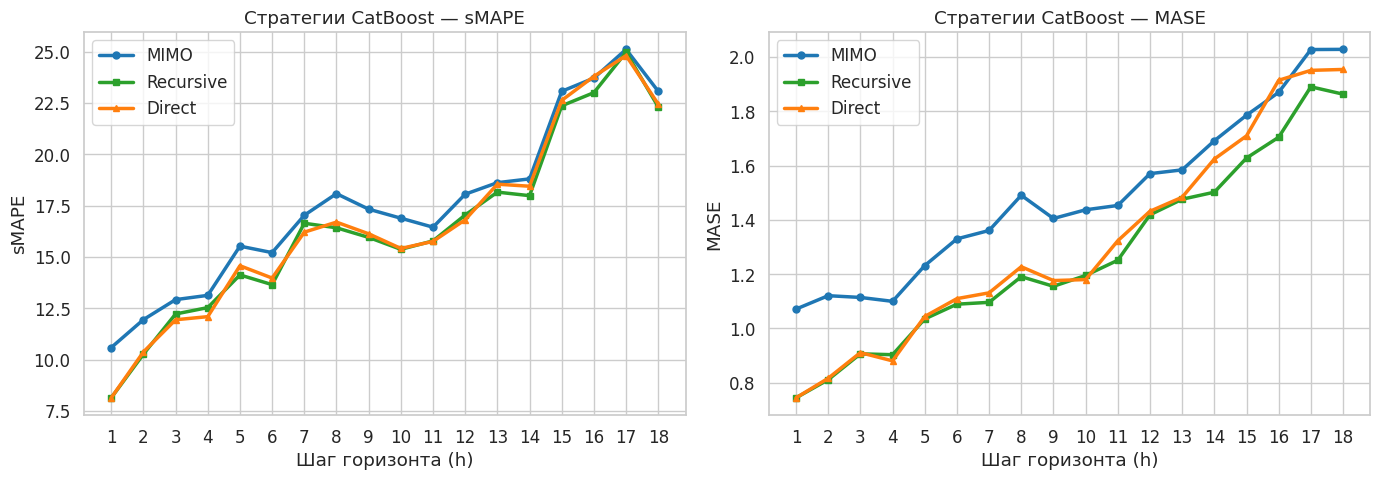

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cb_names = ["CatBoost_MIMO", "CatBoost_Recursive", "CatBoost_Direct"]
cb_colors = ["#1f77b4", "#2ca02c", "#ff7f0e"]
cb_markers = ["o", "s", "^"]

for ax, metric in zip(axes, ["sMAPE", "MASE"]):
    for name, color, marker in zip(cb_names, cb_colors, cb_markers):
        df = all_per_step[name]
        ax.plot(df["h"], df[metric],
                label=name.replace("CatBoost_", ""),
                color=color, linewidth=2.5, marker=marker, markersize=5)

    ax.set_xlabel("Шаг горизонта (h)")
    ax.set_ylabel(metric)
    ax.set_title(f"Стратегии CatBoost — {metric}")
    ax.legend()
    ax.set_xticks(range(1, HORIZON + 1))
    ax.grid(True)

plt.tight_layout()
plt.show()

## Относительная производительность vs SeasonalNaive

Значения < 1 означают, что модель лучше бейзлайна SeasonalNaive на данном шаге горизонта.

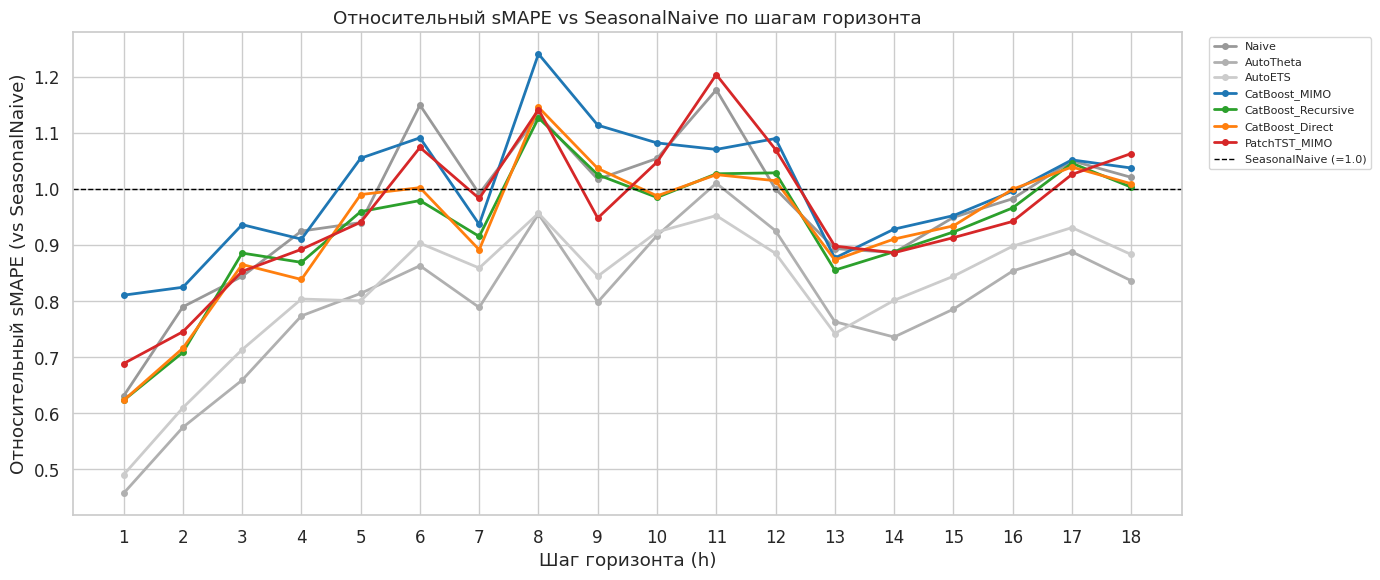

In [ ]:
sn_smape = all_per_step["SeasonalNaive"]["sMAPE"].values

fig, ax = plt.subplots(figsize=(14, 6))

for model_name, df in all_per_step.items():
    if model_name == "SeasonalNaive":
        continue
    ratio = df["sMAPE"].values / sn_smape
    ax.plot(df["h"], ratio, label=model_name,
            color=color_map.get(model_name, None),
            linewidth=2, marker="o", markersize=4)

ax.axhline(y=1.0, color="black", linestyle="--", linewidth=1, label="SeasonalNaive (=1.0)")
ax.set_xlabel("Шаг горизонта (h)")
ax.set_ylabel("Относительный sMAPE (vs SeasonalNaive)")
ax.set_title("Относительный sMAPE vs SeasonalNaive по шагам горизонта")
ax.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_xticks(range(1, HORIZON + 1))
ax.grid(True)

plt.tight_layout()
plt.show()

## Тепловая карта sMAPE: все модели × все шаги

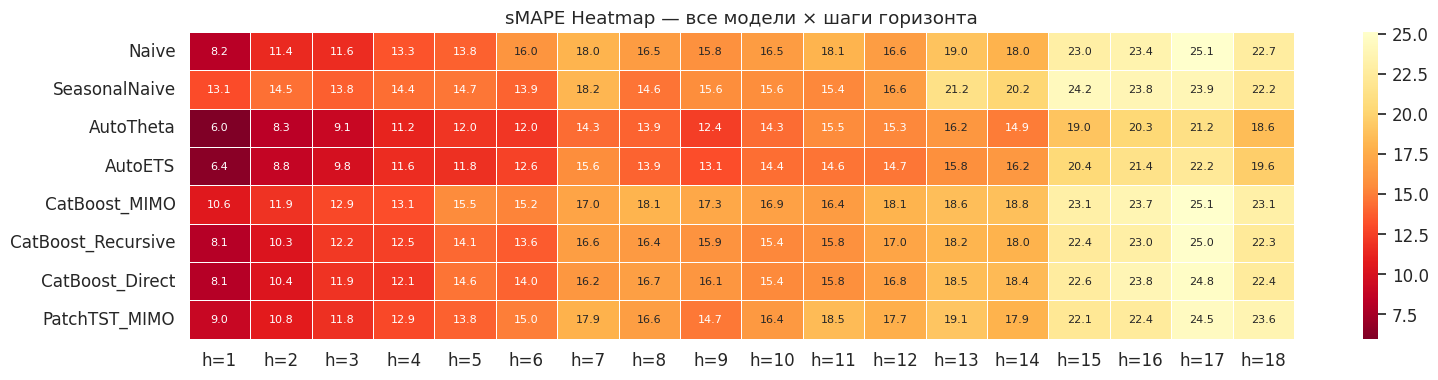

In [ ]:
combined = pd.DataFrame({"h": range(1, HORIZON + 1)})
for model_name, df in all_per_step.items():
    combined[model_name] = df["sMAPE"].values

model_cols = [c for c in combined.columns if c != "h"]
combined["Лучшая модель"] = combined[model_cols].idxmin(axis=1)

matrix = combined[model_cols].T
matrix.columns = [f"h={h}" for h in range(1, HORIZON + 1)]

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(matrix, annot=True, fmt=".1f", cmap="YlOrRd_r",
            ax=ax, linewidths=0.5, annot_kws={"fontsize": 8})
ax.set_title("sMAPE Heatmap — все модели × шаги горизонта")
plt.tight_layout()
plt.show()

## Лучшая модель на каждом шаге горизонта

In [ ]:
# Таблица: лучшая модель на каждом шаге
print("Лучшая модель по sMAPE на каждом шаге горизонта:")
for _, row in combined.iterrows():
    h = int(row["h"])
    best = row["Лучшая модель"]
    val = row[best]
    print(f"  h={h:2d}: {best} ({val:.2f}%)")

Лучшая модель по sMAPE на каждом шаге горизонта:
  h= 1: AutoTheta (5.97%)
  h= 2: AutoTheta (8.33%)
  h= 3: AutoTheta (9.09%)
  h= 4: AutoTheta (11.15%)
  h= 5: AutoETS (11.78%)
  h= 6: AutoTheta (12.03%)
  h= 7: AutoTheta (14.34%)
  h= 8: AutoTheta (13.92%)
  h= 9: AutoTheta (12.42%)
  h=10: AutoTheta (14.31%)
  h=11: AutoETS (14.63%)
  h=12: AutoETS (14.66%)
  h=13: AutoETS (15.76%)
  h=14: AutoTheta (14.90%)
  h=15: AutoTheta (19.03%)
  h=16: AutoTheta (20.32%)
  h=17: AutoTheta (21.20%)
  h=18: AutoTheta (18.60%)


In [ ]:
# Диаграмма: сколько шагов выигрывает каждая модель
from collections import Counter

win_counts = Counter(combined["Лучшая модель"].values)

fig, ax = plt.subplots(figsize=(8, 4))
models_sorted = sorted(win_counts.keys(), key=lambda x: win_counts[x], reverse=True)
bars = ax.barh(
    models_sorted,
    [win_counts[m] for m in models_sorted],
    color=[color_map.get(m, "#888888") for m in models_sorted]
)
ax.set_xlabel("Количество шагов, где модель лучшая")
ax.set_title("Лучшая модель (на скольких шагах горизонта побеждает)")
ax.grid(True, axis="x")
plt.tight_layout()
plt.show()

## Тепловая карта MASE

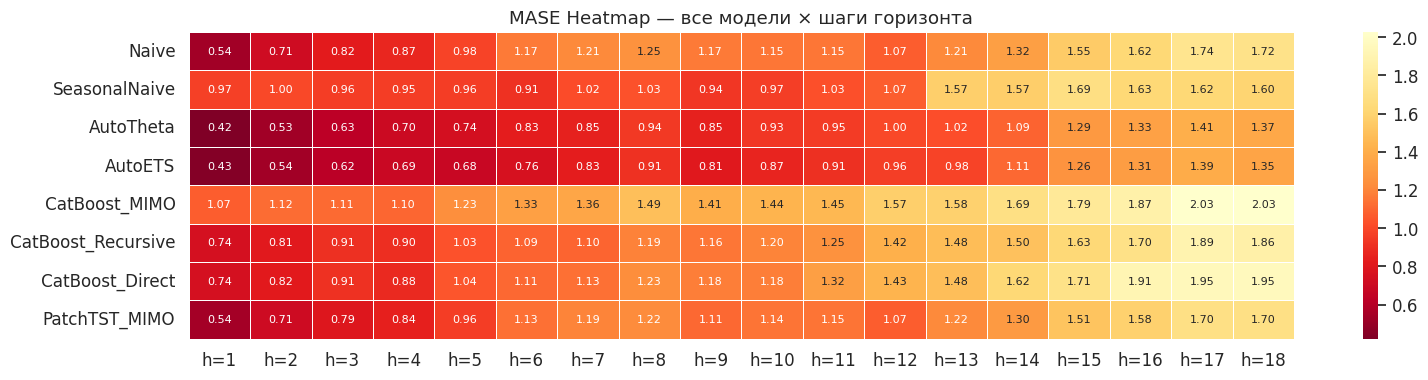

In [ ]:
combined_mase = pd.DataFrame({"h": range(1, HORIZON + 1)})
for model_name, df in all_per_step.items():
    combined_mase[model_name] = df["MASE"].values

model_cols_mase = [c for c in combined_mase.columns if c != "h"]
matrix_mase = combined_mase[model_cols_mase].T
matrix_mase.columns = [f"h={h}" for h in range(1, HORIZON + 1)]

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(matrix_mase, annot=True, fmt=".2f", cmap="YlOrRd_r",
            ax=ax, linewidths=0.5, annot_kws={"fontsize": 8})
ax.set_title("MASE Heatmap — все модели × шаги горизонта")
plt.tight_layout()
plt.show()

## Распределение работы

Проект выполнен индивидуально. Все этапы — подготовка данных, реализация бейзлайнов, обучение моделей, вычисление метрик, анализ и написание выводов — выполнены одним автором.